In [12]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/AI_Ethics"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/AI_Ethics


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [30]:
df = pd.read_excel("Stats_Label_Datasets.xlsx")

In [31]:
df

,Language,Model,Category,Count
0,Hindi,LLaMA,Successful Jailbreak,79
1,Hindi,LLaMA,No Jailbreak,41
2,Hindi,LLaMA,Error,0
3,Hindi,GPT,Successful Jailbreak,81
4,Hindi,GPT,No Jailbreak,39
5,Hindi,GPT,Error,0
6,Hindi,Mistral,Successful Jailbreak,113
7,Hindi,Mistral,No Jailbreak,2
8,Hindi,Mistral,Error,5
9,Hindi,TOTAL,Successful Jailbreak,273


In [32]:
# Filter out 'TOTAL' model rows
df_filtered = df[df['Model'] != 'TOTAL'].copy()

# Calculate Total Attempts for normalization
total_attempts = df_filtered.groupby(['Language', 'Model'])['Count'].sum().reset_index(name='TotalAttempts')


# --- Custom Palettes for Beautification ---
# Category palette: Red for vulnerability, Blue for safety, Gold for error
category_palette = {
    'Successful Jailbreak': '#d73027', # Dark Red
    'No Jailbreak': '#4575b4',         # Dark Blue
    'Error': '#fee090'                 # Light Gold/Yellow
}
# Model palette: Distinct colors for each model
model_palette = {
    'LLaMA': '#1b9e77',  # Teal/Green
    'GPT': '#d95f02',    # Orange/Brown
    'Mistral': '#7570b3' # Purple
}

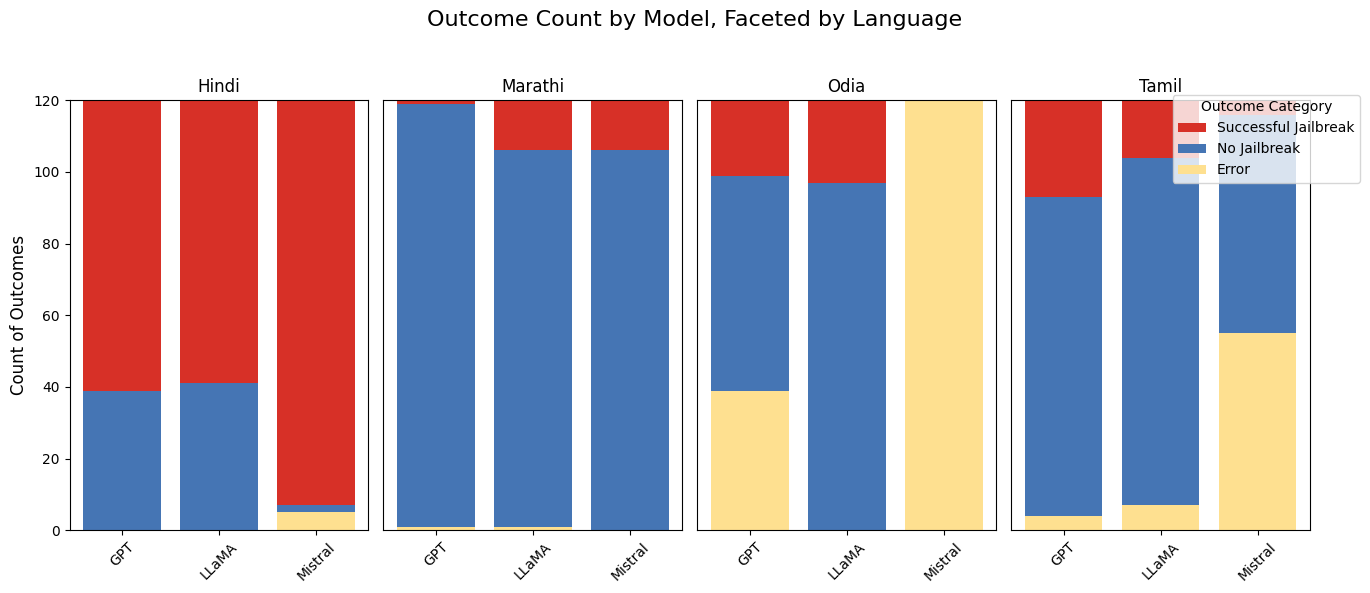

In [33]:
# ----------------------------------------------------------------------
# CHART 1: Stacked Bar Chart (Absolute Outcomes)
# ----------------------------------------------------------------------

# Pivot data for easier stacking
df_stack = df_filtered.pivot_table(index=['Language', 'Model'], columns='Category', values='Count', fill_value=0).reset_index()
languages = df_stack['Language'].unique()
categories = ['Successful Jailbreak', 'No Jailbreak', 'Error']
categories_reversed = categories[::-1] # Plot in reverse order so Successful Jailbreak is at the top

# Create figure and subplots
fig, axes = plt.subplots(1, len(languages), figsize=(14, 6), sharey=True)
fig.suptitle('Outcome Count by Model, Faceted by Language', fontsize=16)

for i, lang in enumerate(languages):
    df_lang = df_stack[df_stack['Language'] == lang].set_index('Model')

    # Initialize base for stacking
    bottom = np.zeros(len(df_lang))

    # Plot each category
    for cat in categories_reversed:
        height = df_lang[cat]
        axes[i].bar(df_lang.index, height, bottom=bottom, label=cat, color=category_palette.get(cat, 'gray'))
        bottom += height

    # Aesthetics
    axes[i].set_title(lang, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].tick_params(axis='y', left=i == 0) # Only show y-ticks for the first subplot

axes[0].set_ylabel('Count of Outcomes', fontsize=12)

# Centralized Legend
handles, labels = axes[0].get_legend_handles_labels()
# Reorder legend to match the stacking order (Successful Jailbreak on top)
handles.reverse()
labels.reverse()
fig.legend(handles, labels, title='Outcome Category', loc='upper right', bbox_to_anchor=(0.98, 0.85))

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show();

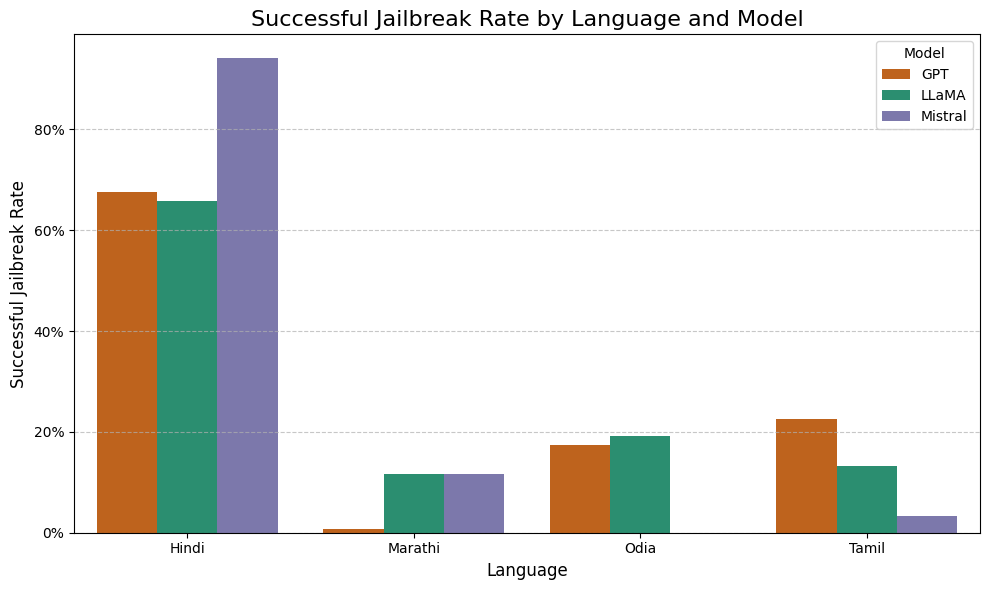

In [34]:
# ----------------------------------------------------------------------
# CHART 2: Grouped Bar Chart of Successful Jailbreak Rate
# ----------------------------------------------------------------------

# Calculate the Successful Jailbreak Rate (recalculated for standalone code)
successful_jailbreak = df_filtered[df_filtered['Category'] == 'Successful Jailbreak'].copy()
successful_jailbreak = successful_jailbreak.rename(columns={'Count': 'SuccessfulJailbreakCount'})
df_rate = pd.merge(total_attempts, successful_jailbreak[['Language', 'Model', 'SuccessfulJailbreakCount']],
                   on=['Language', 'Model'], how='left').fillna(0)
df_rate['JailbreakRate'] = df_rate['SuccessfulJailbreakCount'] / df_rate['TotalAttempts']


plt.figure(figsize=(10, 6))
sns.barplot(data=df_rate, x='Language', y='JailbreakRate', hue='Model', palette=model_palette)
plt.title('Successful Jailbreak Rate by Language and Model', fontsize=16)
plt.ylabel('Successful Jailbreak Rate', fontsize=12)
plt.xlabel('Language', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();

/tmp/ipython-input-1344689450.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = df_heatmap.applymap(format_percent)


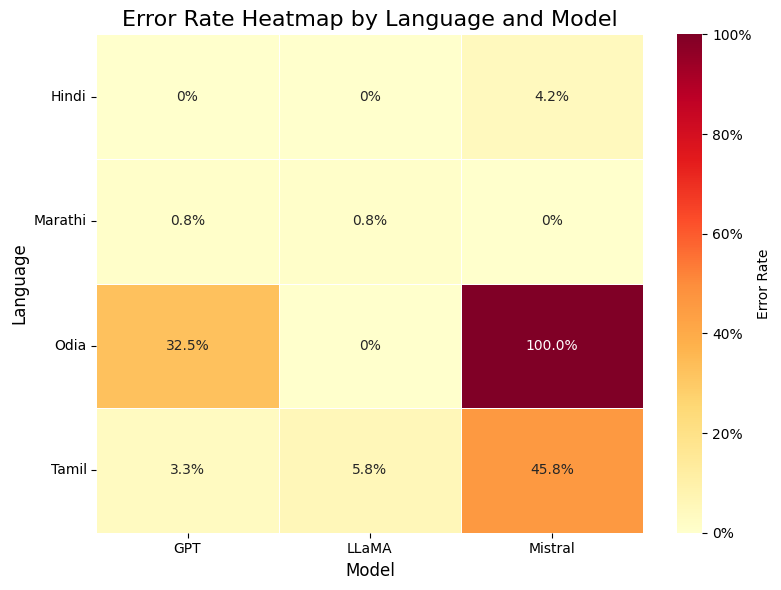

In [35]:
# ----------------------------------------------------------------------
# CHART 3: Heatmap of Error Rate
# ----------------------------------------------------------------------

# Calculate the Error Rate (recalculated for standalone code)
error_counts = df_filtered[df_filtered['Category'] == 'Error'].copy()
error_counts = error_counts.rename(columns={'Count': 'ErrorCount'})
df_error_rate = pd.merge(total_attempts, error_counts[['Language', 'Model', 'ErrorCount']],
                   on=['Language', 'Model'], how='left').fillna(0)
df_error_rate['ErrorRate'] = df_error_rate['ErrorCount'] / df_error_rate['TotalAttempts']

# Pivot data for heatmap
df_heatmap = df_error_rate.pivot_table(index='Language', columns='Model', values='ErrorRate')

plt.figure(figsize=(8, 6))

# Define annotation function to format the percentage string
def format_percent(x):
    return f"{x:.1%}" if x > 0 else "0%"

# Apply the formatting function to the annotations
annot_data = df_heatmap.applymap(format_percent)

sns.heatmap(df_heatmap, annot=annot_data, fmt='s', cmap="YlOrRd", linewidths=.5, linecolor='white',
            cbar_kws={'label': 'Error Rate', 'format': plt.matplotlib.ticker.PercentFormatter(xmax=1.0)})
plt.title('Error Rate Heatmap by Language and Model', fontsize=16)
plt.ylabel('Language', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show();

In [37]:
# Filter only relevant categories
df_filtered = df[df["Category"].isin(["Successful Jailbreak", "No Jailbreak"])]

# Pivot so columns become Success / NoJailbreak counts
pivoted = df_filtered.pivot_table(
    index=["Model", "Language"],
    columns="Category",
    values="Count",
    aggfunc="sum",
    fill_value=0
).reset_index()

# Rename for convenience
pivoted = pivoted.rename(columns={
    "Successful Jailbreak": "success",
    "No Jailbreak": "no_jailbreak"
})

# Compute ASR
pivoted["ASR"] = pivoted["success"] / (pivoted["success"] + pivoted["no_jailbreak"])

# --- ASR per (Model, Language) ---
asr_model_language = pivoted[["Model", "Language", "ASR"]]

# --- ASR per Model ---
asr_model = (
    pivoted.groupby("Model")
           .apply(lambda g: g["success"].sum() / (g["success"].sum() + g["no_jailbreak"].sum()))
           .reset_index(name="ASR")
)

# --- ASR per Language ---
asr_language = (
    pivoted.groupby("Language")
           .apply(lambda g: g["success"].sum() / (g["success"].sum() + g["no_jailbreak"].sum()))
           .reset_index(name="ASR")
)

print("ASR per (Model, Language):")
print(asr_model_language)

print("\nASR per Model:")
print(asr_model)

print("\nASR per Language:")
print(asr_language)

ASR per (Model, Language):
Category    Model Language       ASR
0             GPT    Hindi  0.675000
1             GPT  Marathi  0.008403
2             GPT     Odia  0.259259
3             GPT    Tamil  0.232759
4           LLaMA    Hindi  0.658333
5           LLaMA  Marathi  0.117647
6           LLaMA     Odia  0.191667
7           LLaMA    Tamil  0.141593
8         Mistral    Hindi  0.982609
9         Mistral  Marathi  0.116667
10        Mistral     Odia       NaN
11        Mistral    Tamil  0.061538
12          TOTAL    Hindi  0.769014
13          TOTAL  Marathi  0.081006
14          TOTAL     Odia  0.218905
15          TOTAL    Tamil  0.159864

ASR per Model:
     Model       ASR
0      GPT  0.298165
1    LLaMA  0.279661
2  Mistral  0.436667
3    TOTAL  0.325331

ASR per Language:
  Language       ASR
0    Hindi  0.769014
1  Marathi  0.081006
2     Odia  0.218905
3    Tamil  0.159864


/tmp/ipython-input-4075655359.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["success"].sum() / (g["success"].sum() + g["no_jailbreak"].sum()))
/tmp/ipython-input-4075655359.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["success"].sum() / (g["success"].sum() + g["no_jailbreak"].sum()))


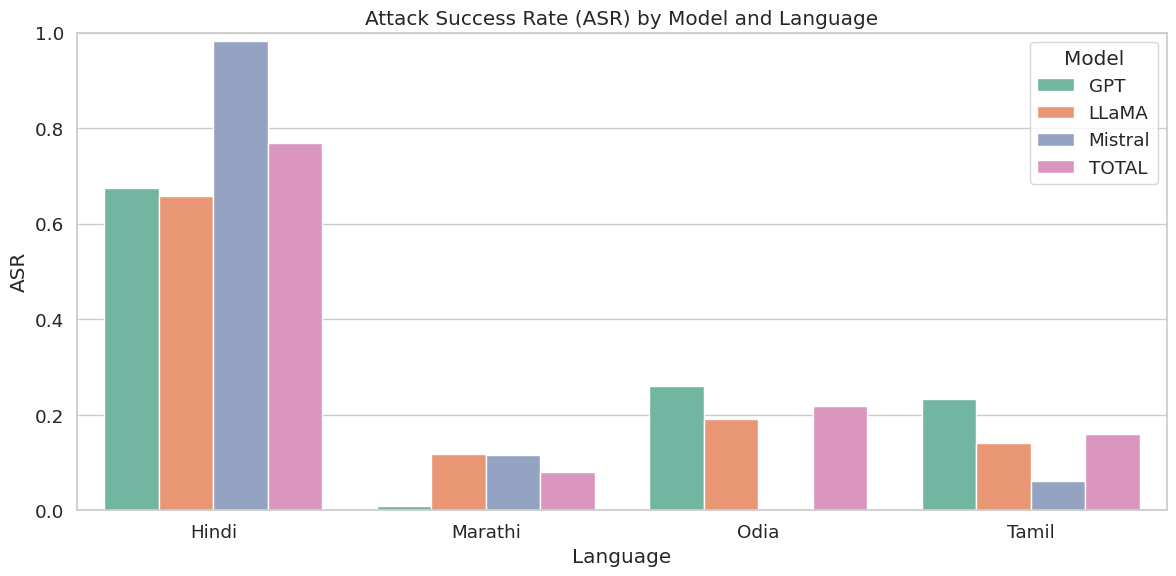

In [38]:
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=asr_model_language,
    x="Language",
    y="ASR",
    hue="Model",
    palette="Set2"
)

plt.title("Attack Success Rate (ASR) by Model and Language")
plt.ylabel("ASR")
plt.xlabel("Language")
plt.ylim(0, 1)

plt.legend(title="Model", frameon=True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1520945017.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1520945017.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


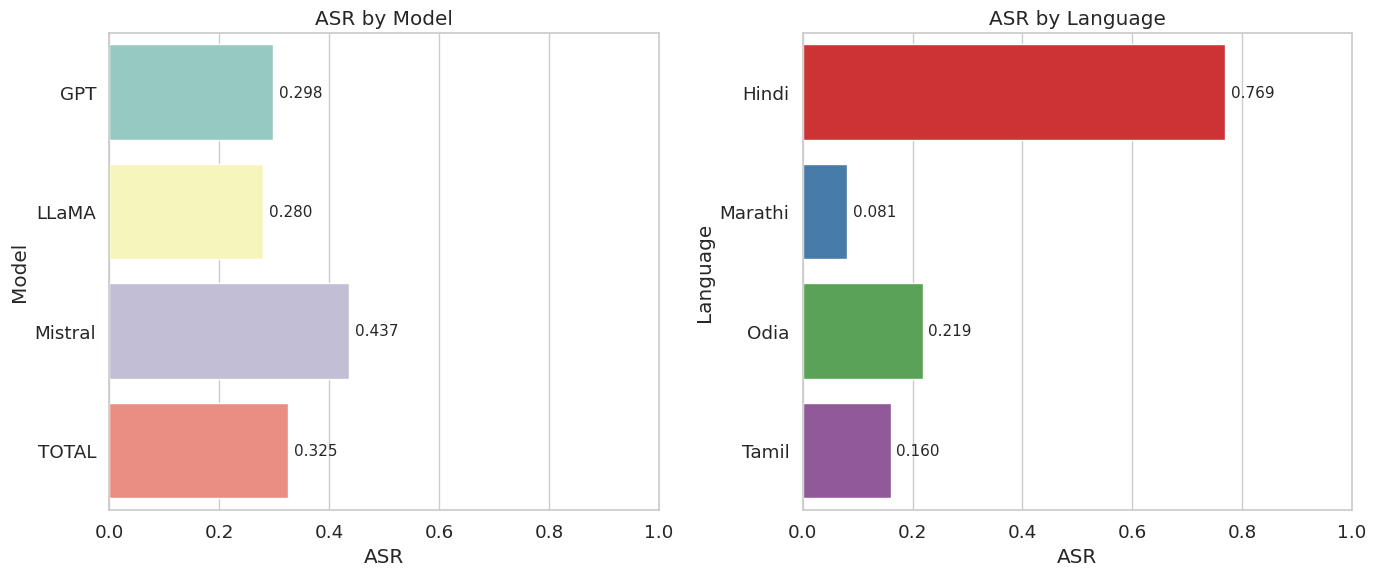

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid", font_scale=1.2)

# --- Left: ASR per Model ---
sns.barplot(
    data=asr_model,
    y="Model",
    x="ASR",
    ax=axes[0],
    palette="Set3"
)
axes[0].set_title("ASR by Model")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("ASR")
axes[0].set_ylabel("Model")

# Add labels
for i, row in asr_model.iterrows():
    axes[0].text(
        row["ASR"] + 0.01,      # Slightly after the bar
        i,                      # y position
        f"{row['ASR']:.3f}",    # formatted number
        va='center',
        fontsize=11
    )

# --- Right: ASR per Language ---
sns.barplot(
    data=asr_language,
    y="Language",
    x="ASR",
    ax=axes[1],
    palette="Set1"
)
axes[1].set_title("ASR by Language")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("ASR")
axes[1].set_ylabel("Language")

# Add labels
for i, row in asr_language.iterrows():
    axes[1].text(
        row["ASR"] + 0.01,
        i,
        f"{row['ASR']:.3f}",
        va='center',
        fontsize=11
    )

plt.tight_layout()
plt.show();